<a href="https://colab.research.google.com/github/sidhu2690/MARL/blob/main/probability_map_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


GRID = 12
N_ROBOTS = 10
ADV_FRAC = 0.5
STEPS = 150
EPSILON = 0.05
CONTRA_THRESH = 0.2
SEED = 40

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

def make_true_map(grid):
  xs, ys = np.meshgrid(np.arange(grid), np.arange(grid))
  field = np.zeros((grid, grid))
  for _ in range(5):
    cx, cy = rng.uniform(0, grid, 2)
    amp = rng.uniform(0.5, 1.0)
    sigma = rng.uniform(1.5, 3.5)
    field += amp * np.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2 * sigma ** 2))
  field = (field - field.min()) / (field.max() - field.min() + 1e-8)
  return field

def make_adv_mask(n_robots, n_adv):
  mask = np.array([False] * (n_robots - n_adv) + [True] * n_adv)
  rng.shuffle(mask)
  return mask

def random_walk(grid, steps):
  pos = rng.integers(0, grid, size=2)
  cells = []
  for _ in range(steps):
    while True:
      move = rng.choice([-1, 0, 1], size=2)
      new_pos = np.clip(pos + move, 0, grid - 1)
      if not np.array_equal(new_pos, pos):
        break
    pos = new_pos
    cells.append(tuple(pos))
  return cells

def report_value(true_val, adversarial, cell):
    if adversarial:
        bias_sign = 1 if (hash(cell) % 2 == 0) else -1
        val = true_val + bias_sign * rng.uniform(0.15, 0.3) + rng.normal(0, 0.05)
    else:
        val = true_val + rng.normal(0, 0.02)
    return float(np.clip(val, 0, 1))


class AlphaNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(3, 16),
      nn.ReLU(),
      nn.Linear(16, 8),
      nn.ReLU(),
      nn.Linear(8, 1),
      nn.Sigmoid(),
    )
  def forward(self, feats):
    return self.net(feats).squeeze(-1)


def train_alpha_net(episodes=400, lr=2e-3):
  alpha_net = AlphaNet().to(DEVICE)
  optimizer = torch.optim.Adam(alpha_net.parameters(), lr=lr)
  loss_history = []

  for ep in range(episodes):
    TRUE_MAP = make_true_map(GRID)
    n_adv = rng.integers(1, int(N_ROBOTS * ADV_FRAC_MAX) + 1)
    is_adv = make_adv_mask(N_ROBOTS, n_adv)
    walks = [random_walk(GRID, STEPS) for _ in range(N_ROBOTS)]

    c = np.zeros(N_ROBOTS)
    D_sum = np.zeros(N_ROBOTS)
    D_n = np.zeros(N_ROBOTS)
    cell_reports = {}
    ep_loss = 0.0

    for t in range(STEPS):
      touched_cells = set()

      for i in range(N_ROBOTS):
        cell = walks[i][t]
        r_i = report_value(TRUE_MAP[cell], is_adv[i], cell)
        others = cell_reports.get(cell, [])

        if others:
          residuals = [abs(r_i - r_j) for _, r_j in others]
          D_sum[i] += float(np.mean(residuals))
          D_n[i] += 1

          for j, r_j in others:
            if abs(r_i - r_j) > CONTRA_THRESH:
              c[i] += 1
              c[j] += 1

        cell_reports.setdefault(cell, []).append((i, r_i))
        touched_cells.add(cell)

      mu_c, sigma_c = c.mean(), c.std()
      z = (c - mu_c) / (sigma_c + EPSILON)
      D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
      c_norm = c / (t + 1)

      feats = torch.tensor(
        np.stack([c_norm, z, D], axis=1),
        dtype=torch.float32,
        device=DEVICE
      )

      alpha = alpha_net(feats)

      step_loss = 0.0

      for cell in touched_cells:
        reports = cell_reports[cell]
        idx = torch.tensor([r for r, _ in reports], device=DEVICE)
        vals = torch.tensor(
          [v for _, v in reports],
          dtype=torch.float32,
          device=DEVICE
        )

        a = alpha[idx]
        M = (a * vals).sum() / (a.sum() + EPSILON)

        step_loss = step_loss + (TRUE_MAP[cell] - M) ** 2

      step_loss = step_loss / len(touched_cells)

      optimizer.zero_grad()
      step_loss.backward()
      optimizer.step()

      ep_loss += step_loss.item()

    loss_history.append(ep_loss / STEPS)

    if (ep + 1) % 100 == 0:
      print(
        f"[alpha_net] episode {ep+1}/{episodes}  "
        f"avg loss {loss_history[-1]:.5f}"
      )

  return alpha_net, loss_history

In [81]:
PRIOR = 0     # M_t(s) prior for never-observed cells

def error_scale_factor(U):
  return (2.0 * U + 1.0) / (U + 1.0) ** 2

In [82]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] using {DEVICE}")

[device] using cpu


In [83]:
def rollout_episode(alpha_net):
  TRUE_MAP = make_true_map(GRID)
  n_adv = rng.integers(1, int(N_ROBOTS * ADV_FRAC_MAX) + 1)
  is_adv = make_adv_mask(N_ROBOTS, n_adv)
  walks = [random_walk(GRID, STEPS) for _ in range(N_ROBOTS)]
  c = np.zeros(N_ROBOTS)
  D_sum = np.zeros(N_ROBOTS)
  D_n = np.zeros(N_ROBOTS)
  cell_reports = {}
  xs, ys, es, qs = [], [], [], []
  for t in range(STEPS):
    for i in range(N_ROBOTS):
      cell = walks[i][t]
      r_i = report_value(TRUE_MAP[cell], is_adv[i], cell)
      others = cell_reports.get(cell, [])
      if others:
        residuals = [abs(r_i - r_j) for _, r_j in others]
        D_sum[i] += float(np.mean(residuals))
        D_n[i] += 1
        for j, r_j in others:
          if abs(r_i - r_j) > CONTRA_THRESH:
            c[i] += 1
            c[j] += 1
      cell_reports.setdefault(cell, []).append((i, r_i))
    mu_c, sigma_c = c.mean(), c.std()
    z = (c - mu_c) / (sigma_c + EPSILON)
    D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
    c_norm = c / (t + 1)
    feats = torch.tensor(np.stack([c_norm, z, D], axis=1), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
      alpha = alpha_net(feats).cpu().numpy()
    W_sum = np.zeros((GRID, GRID))
    A_sum = np.zeros((GRID, GRID))
    N_map = np.zeros((GRID, GRID))
    for cell, reports in cell_reports.items():
      idx = np.array([r for r, _ in reports])
      vals = np.array([v for _, v in reports])
      a = alpha[idx]
      W_sum[cell] = (a * vals).sum()
      A_sum[cell] = a.sum()
      N_map[cell] = len(reports)
    M_t = np.where(A_sum > 0, W_sum / np.maximum(A_sum, 1e-8), PRIOR)
    U_t = A_sum
    N_t = N_map

    e_t = TRUE_MAP - M_t
    err_old = e_t ** 2
    scale = error_scale_factor(U_t)
    Y_t = err_old * scale
    dir_t = np.where(M_t >= TRUE_MAP, 1.0, -1.0)

    xs.append(np.stack([M_t, U_t, N_t]).astype(np.float32))
    ys.append(Y_t.astype(np.float32))        # oracle (for evaluation only)
    es.append(err_old.astype(np.float32))    # error-energy target
    qs.append(dir_t.astype(np.float32))      # sign target
  return xs, ys, es, qs

In [84]:
class GTransformer(nn.Module):
  def __init__(self, in_channels=3, grid=GRID, d_model=32, nhead=4,
               num_layers=2, dim_feedforward=64, dropout=0.0):
    super().__init__()
    self.grid = grid
    self.input_proj = nn.Linear(in_channels, d_model)
    self.pos_embed = nn.Parameter(torch.randn(1, grid * grid, d_model) * 0.02)
    encoder_layer = nn.TransformerEncoderLayer(
      d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
      dropout=dropout, batch_first=True,
    )
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    self.output_proj = nn.Linear(d_model, 1)

  def forward(self, x):
    B, C, H, W = x.shape
    tokens = x.flatten(2).transpose(1, 2)          # (B, H*W, C)
    tokens = self.input_proj(tokens) + self.pos_embed
    out = self.encoder(tokens)                      # (B, H*W, d_model)
    out = self.output_proj(out).squeeze(-1)          # (B, H*W)
    return out.view(B, H, W)


GNet = GTransformer

def predict_R(gnet, X_t):
  with torch.no_grad():
    x = torch.tensor(X_t, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    E_pred = gnet(x).squeeze(0).cpu().numpy()
  E_pred = np.clip(E_pred, 0, None)
  U_t = X_t[1]
  scale = error_scale_factor(U_t)
  return E_pred * scale

In [100]:
class DirTransformer(nn.Module):
  def __init__(self, in_channels=3, grid=GRID, d_model=32, nhead=4,
               num_layers=2, dim_feedforward=64, dropout=0.0):
    super().__init__()
    self.grid = grid
    self.input_proj = nn.Linear(in_channels, d_model)
    self.pos_embed = nn.Parameter(torch.randn(1, grid * grid, d_model) * 0.02)
    encoder_layer = nn.TransformerEncoderLayer(
      d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
      dropout=dropout, batch_first=True,
    )
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    self.output_proj = nn.Linear(d_model, 1)

  def forward(self, x):
    B, C, H, W = x.shape
    tokens = x.flatten(2).transpose(1, 2)
    tokens = self.input_proj(tokens) + self.pos_embed
    out = self.encoder(tokens)
    logit = self.output_proj(out).squeeze(-1)
    return logit.view(B, H, W)


def predict_direction(dirnet, X_t):
  with torch.no_grad():
    x = torch.tensor(X_t, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    logit = dirnet(x).squeeze(0).cpu().numpy()
  return np.where(logit >= 0, 1.0, -1.0)


def predict_local_and_signed(gnet, dirnet, X_t):
  energy = predict_R(gnet, X_t) / np.maximum(error_scale_factor(X_t[1]), 1e-8)
  energy = np.clip(energy, 0, None)
  q = predict_direction(dirnet, X_t)
  e_signed = q * np.sqrt(energy)
  U_t = X_t[1]
  R_local = energy * error_scale_factor(U_t)
  return R_local, energy, q, e_signed

In [86]:
def build_dataset(alpha_net, episodes):
  X_all, E_all, Q_all = [], [], []
  for ep in range(episodes):
    xs, ys, es, qs = rollout_episode(alpha_net)
    X_all.extend(xs)
    E_all.extend(es)
    Q_all.extend(qs)
    if (ep + 1) % 25 == 0:
      print(f"[data] generated {ep+1}/{episodes} episodes "
            f"({len(X_all)} state samples so far)")
  X = torch.tensor(np.stack(X_all), dtype=torch.float32)
  E = torch.tensor(np.stack(E_all), dtype=torch.float32)
  Q = torch.tensor(np.stack(Q_all), dtype=torch.float32)
  return X, E, Q

In [87]:
def train_gnet(X, E, max_epochs=150, lr=1e-3, batch_size=64,
               patience=8, min_delta=1e-4, balance_visited=True):
  gnet = GTransformer(in_channels=X.shape[1]).to(DEVICE)
  optimizer = torch.optim.Adam(gnet.parameters(), lr=lr)
  n = X.shape[0]
  loss_history = []
  best_loss = float("inf")
  bad_epochs = 0
  for epoch in range(max_epochs):
    perm = torch.randperm(n)
    epoch_loss = 0.0
    n_batches = 0
    for start in range(0, n, batch_size):
      idx = perm[start:start + batch_size]
      xb, eb = X[idx].to(DEVICE), E[idx].to(DEVICE)
      pred = gnet(xb)
      if balance_visited:
        visited = (xb[:, 2] > 0).float()
        n_vis = visited.sum().clamp(min=1.0)
        n_unvis = (1 - visited).sum().clamp(min=1.0)
        w = visited / n_vis + (1 - visited) / n_unvis
        loss = ((pred - eb) ** 2 * w).sum() / 2.0
      else:
        loss = ((pred - eb) ** 2).mean()
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()
      n_batches += 1
    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    print(f"[g_f train] epoch {epoch+1}/{max_epochs}  avg loss {avg_loss:.6f}")
    if best_loss - avg_loss > min_delta:
      best_loss = avg_loss
      bad_epochs = 0
    else:
      bad_epochs += 1
      if bad_epochs >= patience:
        print(f"[g_f train] plateaued at epoch {epoch+1}, stopping early")
        break
  return gnet, loss_history

In [88]:
def train_dirnet(X, Q, max_epochs=30, lr=1e-3, batch_size=64,
                  patience=8, min_delta=1e-4):
  dirnet = DirTransformer(in_channels=X.shape[1]).to(DEVICE)
  optimizer = torch.optim.Adam(dirnet.parameters(), lr=lr)
  bce = nn.BCEWithLogitsLoss(reduction="none")
  n = X.shape[0]
  loss_history = []
  best_loss = float("inf")
  bad_epochs = 0
  for epoch in range(max_epochs):
    perm = torch.randperm(n)
    epoch_loss, n_correct, n_total = 0.0, 0.0, 0.0
    n_batches = 0
    for start in range(0, n, batch_size):
      idx = perm[start:start + batch_size]
      xb, qb = X[idx].to(DEVICE), Q[idx].to(DEVICE)
      visited = (xb[:, 2] > 0).float()
      logit = dirnet(xb)
      target01 = (qb + 1.0) / 2.0
      per_cell = bce(logit, target01)
      w = visited / visited.sum().clamp(min=1.0)
      loss = (per_cell * w).sum()
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      with torch.no_grad():
        pred_sign = torch.where(logit >= 0, 1.0, -1.0)
        n_correct += ((pred_sign == qb).float() * visited).sum().item()
        n_total += visited.sum().item()

      epoch_loss += loss.item()
      n_batches += 1
    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    acc = n_correct / max(n_total, 1)
    print(f"[dir_f train] epoch {epoch+1}/{max_epochs}  avg loss {avg_loss:.6f}  "
          f"dir_acc(visited) {acc:.3f}")
    if best_loss - avg_loss > min_delta:
      best_loss = avg_loss
      bad_epochs = 0
    else:
      bad_epochs += 1
      if bad_epochs >= patience:
        print(f"[dir_f train] plateaued at epoch {epoch+1}, stopping early")
        break
  return dirnet, loss_history

In [89]:
def normalize_nonneg(y):
  y = np.clip(y, 0, None)
  s = y.sum()
  if s <= 1e-12:
    return np.full_like(y, 1.0 / y.size)
  return y / s

def kl_divergence(p_true, p_pred, eps=1e-8):
  p_true = np.clip(p_true, eps, None)
  p_pred = np.clip(p_pred, eps, None)
  return float(np.sum(p_true * np.log(p_true / p_pred)))

def topk_overlap(y_true_flat, r_pred_flat, k=5):
  k = min(k, y_true_flat.size)
  true_top = set(np.argsort(y_true_flat)[-k:])
  pred_top = set(np.argsort(r_pred_flat)[-k:])
  return len(true_top & pred_top) / k

In [90]:
def evaluate(gnet, alpha_net, episodes=20, k=30):
  kls, overlaps = [], []
  kls_vis, overlaps_vis = [], []
  kls_unvis, overlaps_unvis = [], []
  sample_X, sample_Y, sample_R = None, None, None
  for ep in range(episodes):
    xs, ys, _es, _qs = rollout_episode(alpha_net)   # ys = oracle Y_t, for eval only
    for X_t, Y_t in zip(xs, ys):
      R_t = predict_R(gnet, X_t)
      N_t = X_t[2]
      p_true = normalize_nonneg(Y_t)
      p_pred = normalize_nonneg(R_t)
      kls.append(kl_divergence(p_true, p_pred))
      overlaps.append(topk_overlap(Y_t.reshape(-1), R_t.reshape(-1), k=k))
      vis_mask = N_t > 0
      if vis_mask.sum() >= k:
        yv, rv = Y_t[vis_mask], R_t[vis_mask]
        kls_vis.append(kl_divergence(normalize_nonneg(yv), normalize_nonneg(rv)))
        overlaps_vis.append(topk_overlap(yv, rv, k=k))
      unvis_mask = N_t == 0
      if unvis_mask.sum() >= k:
        yu, ru = Y_t[unvis_mask], R_t[unvis_mask]
        kls_unvis.append(kl_divergence(normalize_nonneg(yu), normalize_nonneg(ru)))
        overlaps_unvis.append(topk_overlap(yu, ru, k=k))
      if sample_X is None and Y_t.sum() > 1e-6:
        sample_X, sample_Y, sample_R = X_t, Y_t, R_t
  print(f"[g_f eval] FULL GRID   mean KL = {np.mean(kls):.4f}  "
        f"mean top-{k} overlap = {np.mean(overlaps):.3f}")
  print(f"[g_f eval] visited-only    mean KL = {np.mean(kls_vis):.4f}  "
        f"mean top-{k} overlap = {np.mean(overlaps_vis):.3f}  (n={len(kls_vis)})")
  print(f"[g_f eval] unvisited-only  mean KL = {np.mean(kls_unvis):.4f}  "
        f"mean top-{k} overlap = {np.mean(overlaps_unvis):.3f}  (n={len(kls_unvis)})")
  return kls, overlaps, (sample_X, sample_Y, sample_R)

In [91]:
def plot_validation(kls, overlaps, sample, k=30):
  sample_X, sample_Y, sample_R = sample
  p_true = normalize_nonneg(sample_Y)
  p_pred = normalize_nonneg(sample_R)
  fig, axes = plt.subplots(2, 3, figsize=(13, 8))
  axes[0, 0].imshow(sample_X[0], cmap="viridis")
  axes[0, 0].set_title("M_t (trust-weighted estimate)")
  axes[0, 1].imshow(p_true, cmap="magma")
  axes[0, 1].set_title("P_true(s)  (from oracle Y_t, full grid)")
  axes[0, 2].imshow(p_pred, cmap="magma")
  axes[0, 2].set_title("P_pred(s)  (g_f error x analytic scale, full grid)")
  axes[1, 0].hist(kls, bins=30)
  axes[1, 0].set_title("KL(P_true || P_pred) across test states")
  axes[1, 0].set_xlabel("KL divergence")
  axes[1, 1].hist(overlaps, bins=np.linspace(0, 1, 11))
  axes[1, 1].set_title(f"Top-{k} cell overlap across test states")
  axes[1, 1].set_xlabel("fraction overlap")
  axes[1, 2].scatter(sample_Y.reshape(-1), sample_R.reshape(-1), s=10, alpha=0.6)
  axes[1, 2].set_xlabel("oracle Y_t(s)")
  axes[1, 2].set_ylabel("predicted R_t(s)")
  axes[1, 2].set_title("Y_t vs R_t (one state, all cells)")
  for ax in axes[0]:
    plt.colorbar(ax.images[0], ax=ax, fraction=0.046)
  plt.tight_layout()
  plt.savefig("gfunc_validation_transformer.png", dpi=130)
  print("saved plot to gfunc_validation_transformer.png")

In [92]:
def build_agent_maps(cell_reports, n_robots):
  agent_sum = [dict() for _ in range(n_robots)]
  agent_cnt = [dict() for _ in range(n_robots)]
  for cell, reports in cell_reports.items():
    for i, r in reports:
      agent_sum[i][cell] = agent_sum[i].get(cell, 0.0) + r
      agent_cnt[i][cell] = agent_cnt[i].get(cell, 0) + 1
  return agent_sum, agent_cnt


def compute_lambda_total(agent_sum, agent_cnt, M_t, U_t, e_signed, n_robots):
  lam = np.zeros(n_robots)
  for i in range(n_robots):
    for cell, s in agent_sum[i].items():
      r_bar = s / agent_cnt[i][cell]
      u, m = U_t[cell], M_t[cell]
      if u > 0:
        lam[i] += e_signed[cell] * (r_bar - m) / u
  return lam

In [93]:
def predict_global_effect(alpha_net, cell_reports, agent_sum, agent_cnt,
                           c, D_sum, D_n, denom, alpha, lam_total, T_hat):
  feats, meta = [], []
  for s, reports in cell_reports.items():
    reporters = sorted({i for i, _ in reports})
    if not reporters:
      continue
    that = T_hat[s]
    c_hyp = c.copy()
    for i in reporters:
      r_bar = agent_sum[i][s] / agent_cnt[i][s]
      c_hyp[i] = c[i] + float(abs(that - r_bar) > CONTRA_THRESH)
    mu, sigma = c_hyp.mean(), c_hyp.std()
    for i in reporters:
      r_bar = agent_sum[i][s] / agent_cnt[i][s]
      D_i_new = (D_sum[i] + abs(r_bar - that)) / (D_n[i] + 1)
      z_i_new = (c_hyp[i] - mu) / (sigma + EPSILON)
      feats.append([c_hyp[i] / denom, z_i_new, D_i_new])
      meta.append((s, i))
  G_global = np.zeros_like(T_hat)
  if not feats:
    return G_global
  feats = torch.tensor(np.array(feats, dtype=np.float32), device=DEVICE)
  with torch.no_grad():
    alpha_new = alpha_net(feats).cpu().numpy()
  for (s, i), a_new in zip(meta, alpha_new):
    d_alpha = a_new - alpha[i]
    G_global[s] -= lam_total[i] * d_alpha
  return G_global

In [94]:
def simulate_snapshot(alpha_net, steps=STEPS):
  TRUE_MAP = make_true_map(GRID)
  n_adv = rng.integers(1, int(N_ROBOTS * ADV_FRAC_MAX) + 1)
  is_adv = make_adv_mask(N_ROBOTS, n_adv)
  walks = [random_walk(GRID, steps) for _ in range(N_ROBOTS)]
  c = np.zeros(N_ROBOTS)
  D_sum = np.zeros(N_ROBOTS)
  D_n = np.zeros(N_ROBOTS)
  cell_reports = {}
  for t in range(steps):
    for i in range(N_ROBOTS):
      cell = walks[i][t]
      r_i = report_value(TRUE_MAP[cell], is_adv[i], cell)
      others = cell_reports.get(cell, [])
      if others:
        residuals = [abs(r_i - r_j) for _, r_j in others]
        D_sum[i] += float(np.mean(residuals))
        D_n[i] += 1
        for j, r_j in others:
          if abs(r_i - r_j) > CONTRA_THRESH:
            c[i] += 1
            c[j] += 1
      cell_reports.setdefault(cell, []).append((i, r_i))
  mu_c, sigma_c = c.mean(), c.std()
  z = (c - mu_c) / (sigma_c + EPSILON)
  D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
  c_norm = c / steps
  feats = torch.tensor(np.stack([c_norm, z, D], axis=1), dtype=torch.float32, device=DEVICE)
  with torch.no_grad():
    alpha = alpha_net(feats).cpu().numpy()
  W_sum = np.zeros((GRID, GRID))
  A_sum = np.zeros((GRID, GRID))
  N_map = np.zeros((GRID, GRID))
  for cell, reports in cell_reports.items():
    idx = np.array([r for r, _ in reports])
    vals = np.array([v for _, v in reports])
    a = alpha[idx]
    W_sum[cell] = (a * vals).sum()
    A_sum[cell] = a.sum()
    N_map[cell] = len(reports)
  M_t = np.where(A_sum > 0, W_sum / np.maximum(A_sum, 1e-8), PRIOR)
  agent_sum, agent_cnt = build_agent_maps(cell_reports, N_ROBOTS)
  return dict(TRUE_MAP=TRUE_MAP, cell_reports=cell_reports, c=c, D_sum=D_sum, D_n=D_n,
              denom=steps, alpha=alpha, W_sum=W_sum, A_sum=A_sum, M_t=M_t, U_t=A_sum,
              N_t=N_map, agent_sum=agent_sum, agent_cnt=agent_cnt)

In [95]:
def ground_truth_gain(alpha_net, snap):
  TRUE_MAP, cell_reports = snap["TRUE_MAP"], snap["cell_reports"]
  agent_sum, agent_cnt = snap["agent_sum"], snap["agent_cnt"]
  c, D_sum, D_n, denom = snap["c"], snap["D_sum"], snap["D_n"], snap["denom"]
  alpha, W_sum, A_sum, M_t = snap["alpha"], snap["W_sum"], snap["A_sum"], snap["M_t"]

  Y_true = np.zeros((GRID, GRID))

  for s, reports in cell_reports.items():
    reporters = sorted({i for i, _ in reports})
    Tval = TRUE_MAP[s]
    c_hyp = c.copy()
    for i in reporters:
      r_bar = agent_sum[i][s] / agent_cnt[i][s]
      c_hyp[i] = c[i] + float(abs(Tval - r_bar) > CONTRA_THRESH)
    mu, sigma = c_hyp.mean(), c_hyp.std()

    feats = []
    for i in reporters:
      r_bar = agent_sum[i][s] / agent_cnt[i][s]
      D_i_new = (D_sum[i] + abs(r_bar - Tval)) / (D_n[i] + 1)
      z_i_new = (c_hyp[i] - mu) / (sigma + EPSILON)
      feats.append([c_hyp[i] / denom, z_i_new, D_i_new])
    feats = torch.tensor(np.array(feats, dtype=np.float32), device=DEVICE)
    with torch.no_grad():
      alpha_new_vals = alpha_net(feats).cpu().numpy()
    alpha_new = dict(zip(reporters, alpha_new_vals))

    W_after, A_after, affected = W_sum.copy(), A_sum.copy(), set()
    for i in reporters:
      d_alpha = alpha_new[i] - alpha[i]
      for cell in agent_sum[i]:
        W_after[cell] += d_alpha * agent_sum[i][cell]
        A_after[cell] += d_alpha * agent_cnt[i][cell]
        affected.add(cell)
    W_after[s] += Tval
    A_after[s] += 1.0
    affected.add(s)

    old_loss = sum((TRUE_MAP[cell] - M_t[cell]) ** 2 for cell in affected)
    new_loss = sum((TRUE_MAP[cell] - (W_after[cell] / A_after[cell] if A_after[cell] > 0 else PRIOR)) ** 2
                   for cell in affected)
    Y_true[s] = old_loss - new_loss
  return Y_true


In [96]:
def demo_global_effect(alpha_net, gnet, dirnet, n_snapshots=5, k=15):
  corrs, maes, overlaps = [], [], []
  for _ in range(n_snapshots):
    snap = simulate_snapshot(alpha_net)
    X_t = np.stack([snap["M_t"], snap["U_t"], snap["N_t"]]).astype(np.float32)
    R_local, _, _, e_signed = predict_local_and_signed(gnet, dirnet, X_t)
    T_hat = snap["M_t"] - e_signed
    lam_total = compute_lambda_total(snap["agent_sum"], snap["agent_cnt"],
                                      snap["M_t"], snap["U_t"], e_signed, N_ROBOTS)
    G_pred = predict_global_effect(alpha_net, snap["cell_reports"], snap["agent_sum"],
                                    snap["agent_cnt"], snap["c"], snap["D_sum"], snap["D_n"],
                                    snap["denom"], snap["alpha"], lam_total, T_hat)
    y_pred = R_local + G_pred
    Y_true = ground_truth_gain(alpha_net, snap)

    mask = snap["N_t"] > 0
    p, y = y_pred[mask], Y_true[mask]
    corr = float(np.corrcoef(p, y)[0, 1]) if len(p) > 1 else float("nan")
    mae = float(np.mean(np.abs(p - y)))
    ov = topk_overlap(y, p, k=k)
    corrs.append(corr); maes.append(mae); overlaps.append(ov)
    print(f"[global effect] corr={corr:.3f}  MAE={mae:.5f}  top-{k} overlap={ov:.3f}  cells={mask.sum()}")

  print(f"[global effect] mean corr={np.nanmean(corrs):.3f}  "
        f"mean MAE={np.mean(maes):.5f}  mean top-{k} overlap={np.mean(overlaps):.3f}")

In [97]:
def evaluate_global_kl(alpha_net, gnet, dirnet, n_snapshots=20):
  kl_total, kl_local = [], []
  for _ in range(n_snapshots):
    snap = simulate_snapshot(alpha_net)
    X_t = np.stack([snap["M_t"], snap["U_t"], snap["N_t"]]).astype(np.float32)
    R_local, _, _, e_signed = predict_local_and_signed(gnet, dirnet, X_t)
    T_hat = snap["M_t"] - e_signed
    lam_total = compute_lambda_total(snap["agent_sum"], snap["agent_cnt"],
                                      snap["M_t"], snap["U_t"], e_signed, N_ROBOTS)
    G_pred = predict_global_effect(alpha_net, snap["cell_reports"], snap["agent_sum"],
                                    snap["agent_cnt"], snap["c"], snap["D_sum"], snap["D_n"],
                                    snap["denom"], snap["alpha"], lam_total, T_hat)
    y_pred_total = R_local + G_pred
    Y_true = ground_truth_gain(alpha_net, snap)

    p_true = normalize_nonneg(Y_true)
    kl_total.append(kl_divergence(p_true, normalize_nonneg(y_pred_total)))
    kl_local.append(kl_divergence(p_true, normalize_nonneg(R_local)))

  print(f"[global KL] mean KL(Y_true_global || y_pred_total=local+global) = {np.mean(kl_total):.4f}")
  print(f"[global KL] mean KL(Y_true_global || y_local_only)              = {np.mean(kl_local):.4f}")
  return kl_total, kl_local

In [98]:
def plot_global_comparison(alpha_net, gnet, dirnet, snap=None,
                            filename="global_effect_comparison.png"):
  if snap is None:
    snap = simulate_snapshot(alpha_net)

  X_t = np.stack([snap["M_t"], snap["U_t"], snap["N_t"]]).astype(np.float32)
  R_local, _, _, e_signed = predict_local_and_signed(gnet, dirnet, X_t)
  T_hat = snap["M_t"] - e_signed
  lam_total = compute_lambda_total(snap["agent_sum"], snap["agent_cnt"],
                                    snap["M_t"], snap["U_t"], e_signed, N_ROBOTS)
  G_pred = predict_global_effect(alpha_net, snap["cell_reports"], snap["agent_sum"],
                                  snap["agent_cnt"], snap["c"], snap["D_sum"], snap["D_n"],
                                  snap["denom"], snap["alpha"], lam_total, T_hat)
  y_pred_total = R_local + G_pred
  Y_true = ground_truth_gain(alpha_net, snap)

  mask = snap["N_t"] > 0
  R_local_m = np.where(mask, R_local, np.nan)
  y_pred_total_m = np.where(mask, y_pred_total, np.nan)
  Y_true_m = np.where(mask, Y_true, np.nan)

  fig, axes = plt.subplots(1, 4, figsize=(20, 5))
  im0 = axes[0].imshow(snap["TRUE_MAP"], cmap="viridis")
  axes[0].set_title("Ground truth T(s)")
  im1 = axes[1].imshow(Y_true_m, cmap="magma")
  axes[1].set_title("Y_true (local + global, brute force)")
  im2 = axes[2].imshow(R_local_m, cmap="magma")
  axes[2].set_title("y_pred (local only)")
  im3 = axes[3].imshow(y_pred_total_m, cmap="magma")
  axes[3].set_title("y_pred (local + global)")
  for ax, im in zip(axes, [im0, im1, im2, im3]):
    plt.colorbar(im, ax=ax, fraction=0.046)
  plt.tight_layout()
  plt.savefig(filename, dpi=130)
  print(f"saved plot to {filename}")

  p_true = normalize_nonneg(Y_true)
  print(f"[compare] KL(Y_true || local_only)  = {kl_divergence(p_true, normalize_nonneg(R_local)):.4f}")
  print(f"[compare] KL(Y_true || local+global) = {kl_divergence(p_true, normalize_nonneg(y_pred_total)):.4f}")
  return snap, Y_true, R_local, y_pred_total

## TEST RUN

=== training alpha_net ===

=== generating training data (3 channels: M_t, U_t, N_t) ===
dataset: torch.Size([15000, 3, 12, 12]) torch.Size([15000, 12, 12]) torch.Size([15000, 12, 12])  E stats: 0.0 1.0 0.03609049692749977

=== training g_f (energy network, Transformer, full grid, visited/unvisited loss-balanced) ===

=== training dir_f (separate direction network, visited cells only) ===

=== validating g_f (Y_t reconstructed as e_pred^2 * scale(U), with visited/unvisited breakdown) ===
[g_f eval] FULL GRID   mean KL = 1.7531  mean top-30 overlap = 0.508
[g_f eval] visited-only    mean KL = 4.1782  mean top-30 overlap = 0.432  (n=1470)
[g_f eval] unvisited-only  mean KL = 0.5118  mean top-30 overlap = 0.648  (n=364)
saved plot to gfunc_validation_transformer.png

=== verifying predicted global effect against brute-force ground truth ===
[global effect] corr=0.965  MAE=0.00139  top-15 overlap=0.333  cells=139
[global effect] corr=0.669  MAE=0.00407  top-15 overlap=0.467  cells=142
[glo

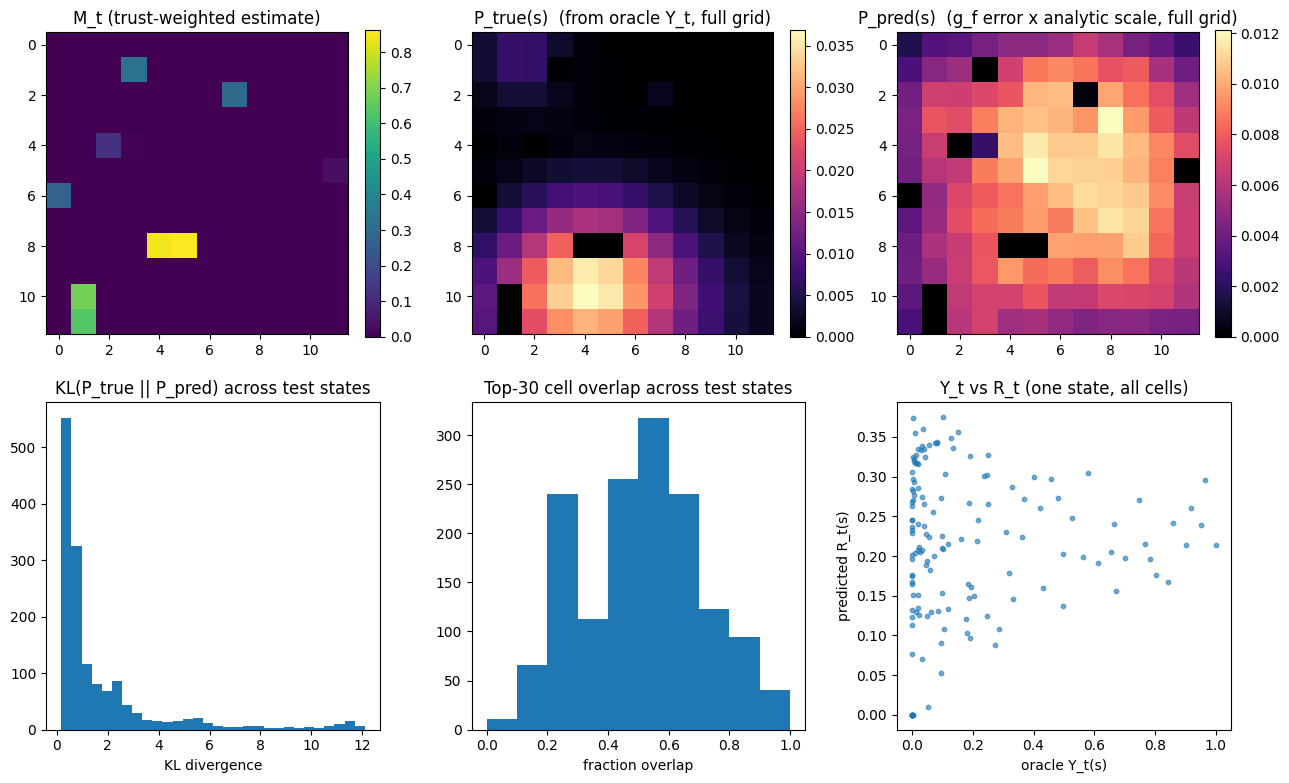

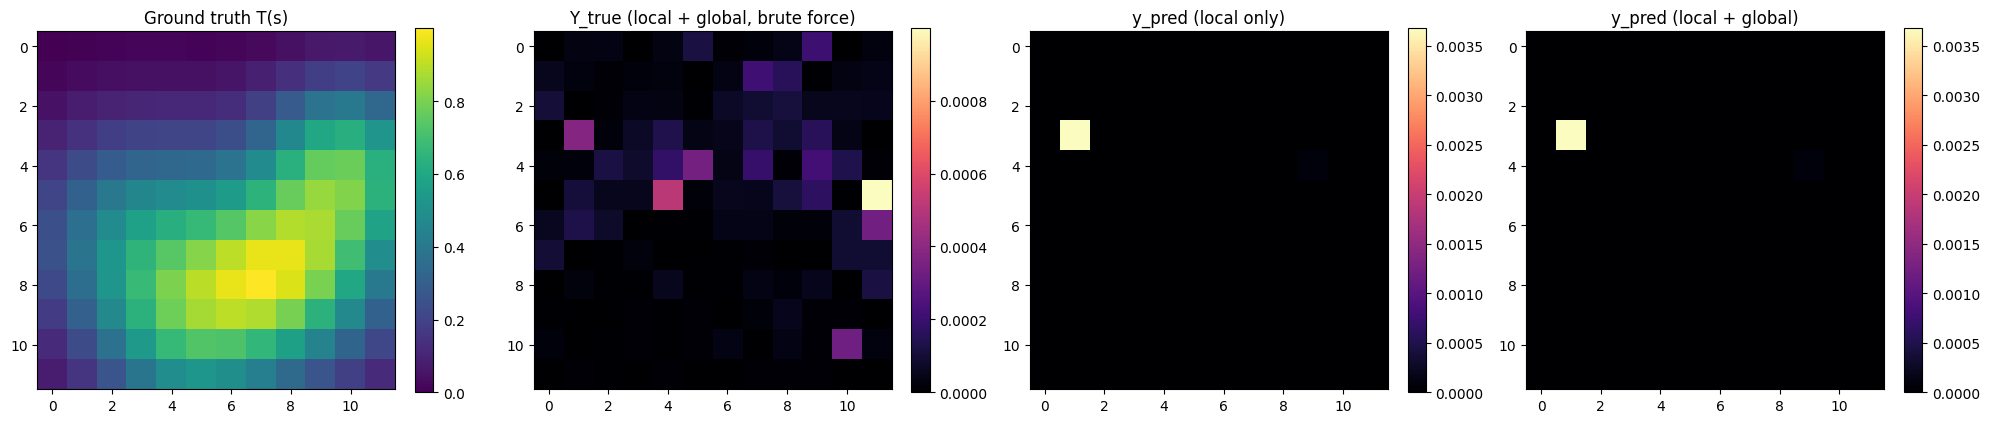

In [102]:
if __name__ == "__main__":
  ALPHA_EPISODES = 50
  DATA_EPISODES = 100
  G_MAX_EPOCHS = 2
  DIR_MAX_EPOCHS = 2
  EVAL_EPISODES = 10

  print("=== training alpha_net ===")
  #alpha_net, alpha_loss = train_alpha_net(episodes=ALPHA_EPISODES)

  print("\n=== generating training data (3 channels: M_t, U_t, N_t) ===")
  #X, E, Q = build_dataset(alpha_net, episodes=DATA_EPISODES)
  print("dataset:", X.shape, E.shape, Q.shape, " E stats:",
        float(E.min()), float(E.max()), float(E.mean()))

  print("\n=== training g_f (energy network, Transformer, full grid, "
        "visited/unvisited loss-balanced) ===")
  #gnet, g_loss = train_gnet(X, E, max_epochs=G_MAX_EPOCHS)

  print("\n=== training dir_f (separate direction network, visited cells only) ===")
  #dirnet, dir_loss = train_dirnet(X, Q, max_epochs=DIR_MAX_EPOCHS)

  print("\n=== validating g_f (Y_t reconstructed as e_pred^2 * scale(U), "
        "with visited/unvisited breakdown) ===")
  kls, overlaps, sample = evaluate(gnet, alpha_net, episodes=EVAL_EPISODES)
  plot_validation(kls, overlaps, sample)

  print("\n=== verifying predicted global effect against brute-force ground truth ===")
  demo_global_effect(alpha_net, gnet, dirnet, n_snapshots=5)

  print("\n=== KL: prediction vs full (local+global) ground truth ===")
  evaluate_global_kl(alpha_net, gnet, dirnet, n_snapshots=20)

  print("\n=== plotting truth vs Y_true vs local-only vs local+global ===")
  plot_global_comparison(alpha_net, gnet, dirnet)

  torch.save(alpha_net.state_dict(), "alpha_net.pt")
  torch.save(gnet.state_dict(), "gnet_transformer.pt")
  torch.save(dirnet.state_dict(), "dirnet_transformer.pt")
  print("\nsaved alpha_net.pt, gnet_transformer.pt, dirnet_transformer.pt")